# Compare different methods
Compare several methods in integrating the label-free proteomics data, both qualitatively and quantitatively:
- ProtInt cVAE, dropout curve, adversarial training
- MOBER
- Celligner (already computed in the script 05.3.1, here I'll just import the transformed matrix to )
- ComBat
- limma
- Harmony

For all methods, uses the per-protein, z-transformed, 50% filtered data. Here I'm trying first with the data where missing values were replaced by -7.5. After this I'll try the methods with missing values replaced by 0 (i.e. the mean of each protein).

Compute the iLISI and cLISI scores. For the deep learning methods (own method & MOBER), compute the average across 5 seeds. Make an associated UMAP per method as well as the scores.

In [1]:
%load_ext autoreload
%autoreload 2
import os, subprocess, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import torch

In [ ]:
import yaml
with open("../../config/config.local.yaml", "r") as f:
    config = yaml.safe_load(f)
basedir = config['code_dir']

anndata_input_dir = os.path.join(config['output_data_dir'], 
                         "processed_proteomics_data", 
                         "1_1_9_ProCan_FDL_PanCancer_merged_tissue20.h5ad"
)  # where the tumor and cell line data, in anndata format, are stored

data_output_dir = os.path.join(config['output_data_dir'], "benchmark_model")  # where the output of protint and MOBER will be stored, will be overwritten per run
fig_output_dir = os.path.join(config["output_plot_dir"], "benchmark_model")
if not os.path.exists(data_output_dir):
    os.makedirs(data_output_dir)
if not os.path.exists(fig_output_dir):
    os.makedirs(fig_output_dir)

In [3]:
# directory of the celligner result
data_celligner_dir = os.path.join(config['output_data_dir'], "celligner_integration")
filename_celligner = "transformed_data_celligner_FDL_Procan.csv"

In [25]:
from Utils.color_palette import tissue_palette
from Utils.plot_functions import plot_detected_reconstructed_imputed_histogram
from Utils.helper_functions import run_lisi_at_k
from Utils.simple_batch_correction_methods import combat_batch_correct, limma_batch_correct, harmony_batch_correct

In [5]:
from mober.core.projection import load_model as mober_load_model
from mober.core.projection import do_projection as mober_do_projection

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [7]:
result_iLISI = {"original": [],
                "ProtInt": [],
                "MOBER": [],
                "Celligner": [],
                "ComBat": [],
                "limma": [],
                "Harmony": []}
result_cLISI_tissue = {"original": [],
                      "ProtInt": [],
                      "MOBER": [],
                      "Celligner": [],
                      "ComBat": [],
                      "limma": [],
                      "Harmony": []}
project_onto = ["FDL_patient", "ProCan_cell_line"]

In [8]:
adata = sc.read_h5ad(anndata_input_dir)

## ProtInt method

In [9]:
## Run ProtInt over several seeds and get the LISI scores
METHOD_KEY = "ProtInt"
SEEDS = [11,12,13,14,15]



for seed in SEEDS:

    print(f"[RUN] seed={seed}", flush=True)

    # overwrite previous model
    if os.path.exists(data_output_dir):
        shutil.rmtree(data_output_dir)
    os.makedirs(data_output_dir, exist_ok=True)

    # ------------------------------------------------------------
    # train
    # ------------------------------------------------------------
    cmd = [
        "protint", "train",
        "--train_file", anndata_input_dir,
        "--hidden_dims", "128 64",
        "--encoding_dim", "32",
        "--batch_size", "512",
        "--epochs", "3000",
        "--batch_lr", "1e-3",
        "--src_adv_lr", "1e-3",
        "--kl_weight", "1e-6",
        "--dropout_weight", "0.1",
        "--src_adv_weight", "100",
        "--cyc_weight", "0",
        "--output_dir", data_output_dir,
        "--random_seed", str(seed),
    ]

    result = subprocess.run(cmd, check=False)

    # ------------------------------------------------------------
    # projection
    # ------------------------------------------------------------
    cmd = [
        "protint", "projection",
        "--projection_file", anndata_input_dir,
        "--model_dir", os.path.join(data_output_dir, "models"),
        "--onto", "FDL_patient",
        "--output_file", os.path.join(data_output_dir, "protint_result_projection.h5ad"),
    ]

    result = subprocess.run(cmd, check=False)

    projected_adata = sc.read_h5ad(os.path.join(data_output_dir, "protint_result_projection.h5ad"))
    # ------------------------------------------------------------
    # LISI
    # ------------------------------------------------------------
    metrics = run_lisi_at_k(
        projected_adata,
        ks=[15],
        batch_key="data_source",
        prefix="ProtInt",
        n_pcs=50,
    )

    result_iLISI[METHOD_KEY].append(metrics[f"ProtInt_k15_iLISI"])
    result_cLISI_tissue[METHOD_KEY].append(metrics[f"ProtInt_k15_cLISI_tissue"])

[RUN] seed=11


/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Using device: cpu


/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loaded model epoch: 2999, loss 2393.76660673732
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
[RUN] seed=12


...

Loaded model epoch: 2999, loss 2399.442846328539
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
[RUN] seed=15


/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Using device: cpu


/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loaded model epoch: 2999, loss 2343.4380204390613
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50


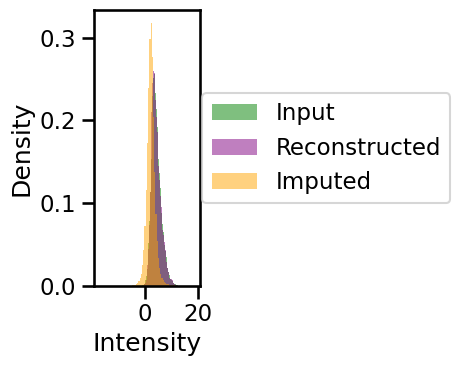

In [10]:
projected_adata.layers["detected"] = adata.layers["detected"]
plot_detected_reconstructed_imputed_histogram(
    adata,
    projected_adata,
    bins=80,
)

## MOBER method
Use the MOBER method on the data, code of the model was revised for better clarity

In [11]:
METHOD_KEY = "MOBER"
K = 15
SEEDS = [11,12,13,14,15]
for seed in SEEDS:

    print(f"[RUN] MOBER seed={seed}", flush=True)

    # overwrite previous model
    if os.path.exists(data_output_dir):
        shutil.rmtree(data_output_dir)
    os.makedirs(data_output_dir, exist_ok=True)

    # ------------------------------------------------------------
    # train
    # ------------------------------------------------------------
    !mober train --train_file $anndata_input_dir --output_dir $data_output_dir --epochs 3000 --batch_size 128 --random_seed $seed

    # ------------------------------------------------------------
    # load model
    # ------------------------------------------------------------
    model_path = os.path.join(data_output_dir, "models")
    model, features, label_encode = mober_load_model(model_path, device=device)

    adata_use = adata[:, features].copy()

    # ------------------------------------------------------------
    # projection
    # ------------------------------------------------------------
    projected_adata, _ = mober_do_projection(
        model,
        adata_use,
        "FDL_patient",
        label_encode,
        device
    )


    # ------------------------------------------------------------
    # LISI
    # ------------------------------------------------------------
    n_pcs_use = min(50, projected_adata.X.shape[1])

    metrics = run_lisi_at_k(
        projected_adata,
        ks=[15],
        batch_key="data_source",
        prefix="MOBER",
        n_pcs=50,
    )

    result_iLISI[METHOD_KEY].append(metrics[f"MOBER_k15_iLISI"])
    result_cLISI_tissue[METHOD_KEY].append(metrics[f"MOBER_k15_cLISI_tissue"])

[RUN] MOBER seed=11


/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
Using device: cpu
Loaded model epoch: 2999, loss 0.5602011626458006
[LISI:MOBER] use_rep=None, computing PCA with n_pcs=50
[LISI:MOBER] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
[RUN] MOBER seed=12
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (

In [12]:
# save the projection results for MOBER (a representative seed)
projected_adata.write_h5ad(os.path.join(data_output_dir, "mober_result_projection.h5ad"))

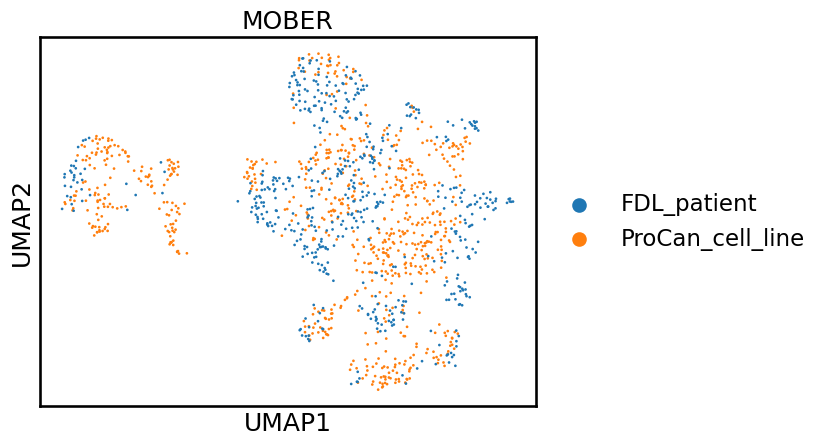

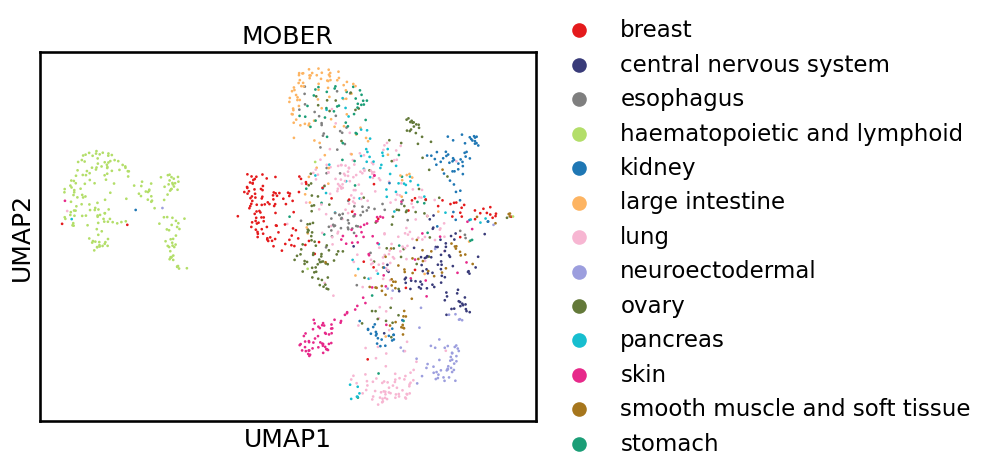

In [13]:
# plot UMAP of the last run (i.e. a representative seed)
sc.pp.pca(projected_adata, n_comps=50)
sc.pp.neighbors(projected_adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(projected_adata)

# ------------------------------------------------------------
# UMAP plots
# ------------------------------------------------------------
sc.pl.umap(
    projected_adata,
    color="data_source",
    legend_loc="right margin",
    frameon=True,
    size=15,
    title="MOBER",
)

sc.pl.umap(
    projected_adata,
    color="joint tissue type",
    legend_loc="right margin",
    frameon=True,
    palette=tissue_palette,
    size=15,
    title="MOBER"
)

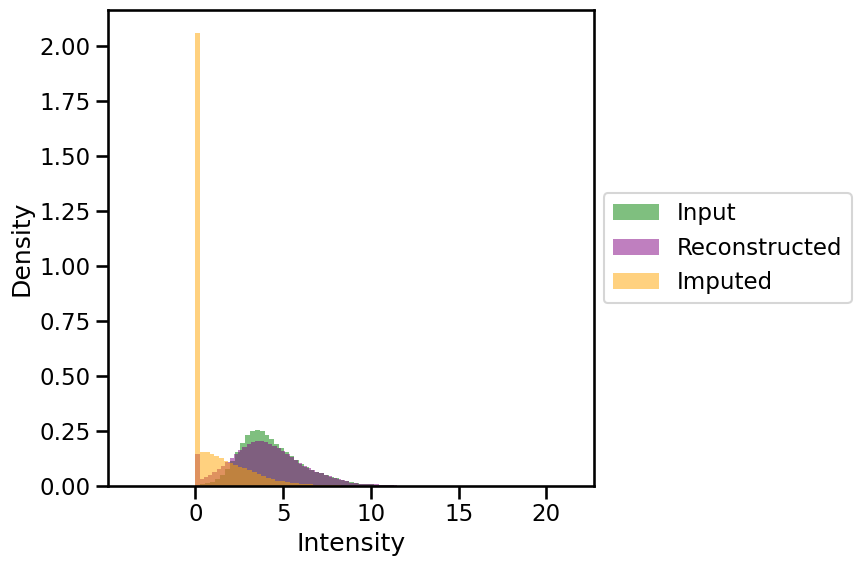

In [14]:
projected_adata.layers["detected"] = adata.layers["detected"]
plot_detected_reconstructed_imputed_histogram(
    adata,
    projected_adata,
    bins=80,
    figsize=(9, 6)
)

### Celligner 
Load the Celligner-transformed result and compute the LISI scores

In [15]:
data_celligner_matrix = pd.read_csv(os.path.join(data_celligner_dir, filename_celligner), index_col=0)
aligned_df = data_celligner_matrix.loc[adata.obs_names, adata.var_names]
adata_celligner = sc.AnnData(
    X=aligned_df.values,
    obs=adata.obs.copy(),
    var=adata.var.copy(),
)
adata_celligner.obs_names = adata.obs_names.copy()
adata_celligner.var_names = adata.var_names.copy()
adata_celligner

AnnData object with n_obs × n_vars = 1321 × 6251
    obs: 'index', 'Cancer type', 'Cancer subtype', 'Tissue type', 'data_source', 'joint tissue type', 'joint Cancer type', 'joint Cancer subtype', 'matching cancer type', 'matching cancer subtype'
    var: 'UniprotID', 'organism', 'missing_pct', 'median_abundance'

FileNotFoundError: [Errno 2] No such file or directory: 'figures/umap/share/home/tacongqu/projects/cellLine_patient_project/notebooks/04_plots/benchmark_model/celligner_umap_data_source.pdf'

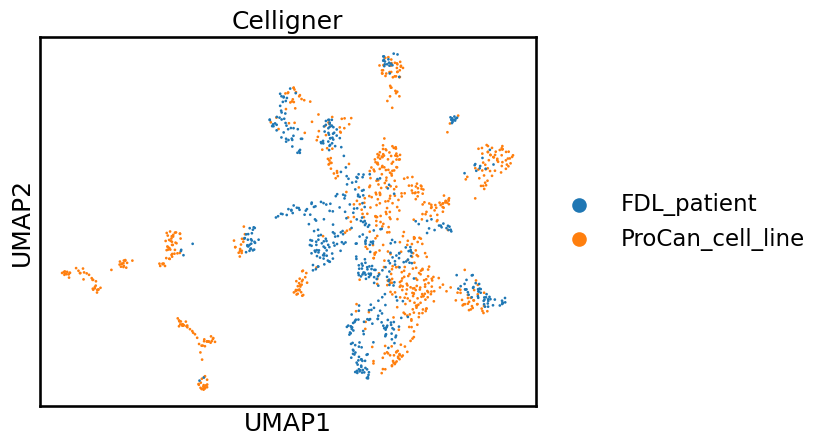

In [ ]:
# ------------------------------------------------------------
# PCA + neighbors + UMAP
# ------------------------------------------------------------

sc.pp.pca(adata_celligner, n_comps=50)
sc.pp.neighbors(adata_celligner, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_celligner)

# ------------------------------------------------------------
# UMAP plots
# ------------------------------------------------------------
sc.pl.umap(
    adata_celligner,
    color="data_source",
    legend_loc="right margin",
    frameon=True,
    size=15,
    title="Celligner",
)


fig = sc.pl.umap(
    adata_celligner,
    color="joint tissue type",
    legend_loc="right margin",
    frameon=True,
    palette=tissue_palette,
    size=15,
    title="Celligner",
)
fig.savefig(fname=os.path.join(fig_output_dir,"celligner_umap_tissue.pdf"))
# ------------------------------------------------------------
# LISI
# ------------------------------------------------------------
lisi_celligner = run_lisi_at_k(
    adata_celligner,
    ks=[15],
    batch_key="data_source",
    prefix="Celligner",
    n_pcs=50
)

print(lisi_celligner)

# store in existing result dicts
result_iLISI["Celligner"] = np.array([lisi_celligner["Celligner_k15_iLISI"]])
result_cLISI_tissue["Celligner"] = np.array([lisi_celligner["Celligner_k15_cLISI_tissue"]])

### Original data
Compute LISI scores for the un-transformed data

In [17]:
# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------
sc.pp.pca(adata, n_comps=50)

# ------------------------------------------------------------
# LISI
# ------------------------------------------------------------
lisi_original = run_lisi_at_k(
    adata,
    ks=[15],
    batch_key="data_source",
    prefix="original",
    n_pcs=50,
)

print(lisi_original)

# ------------------------------------------------------------
# store results
# ------------------------------------------------------------
result_iLISI["original"] = np.array([lisi_original["original_k15_iLISI"]])
result_cLISI_tissue["original"] = np.array([lisi_original["original_k15_cLISI_tissue"]])

[LISI:original] use_rep=None, computing PCA with n_pcs=50
[LISI:original] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
{'original_k15_iLISI': 0.0, 'original_k15_cLISI_tissue': 0.8634402561133966, 'original_k15_cLISI_ctype': 0.9288176945309863, 'original_k15_cLISI_csubtype': 0.962499026970252}


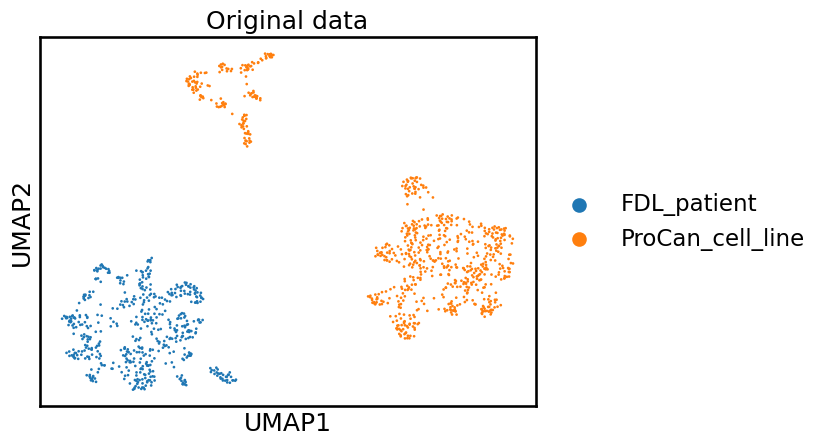

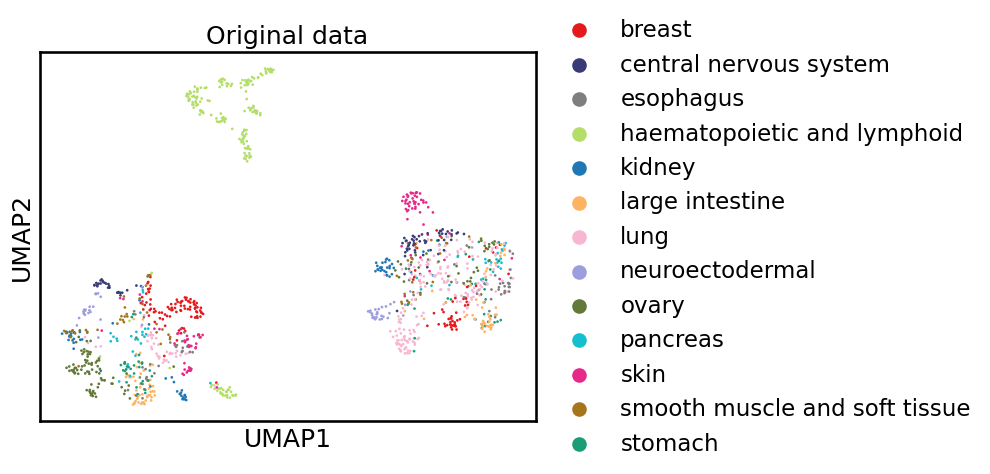

In [18]:
sc.pl.umap(
    adata,
    color="data_source",
    legend_loc="right margin",
    frameon=True,
    size=15,
    title="Original data",
)

sc.pl.umap(
    adata,
    color="joint tissue type",
    legend_loc="right margin",
    frameon=True,
    palette=tissue_palette,
    size=15,
    title="Original data"
)

### Simple batch correction methods
ComBat, limma, harmony

In [28]:
%pip install "harmonypy==0.0.10"

  Using cached harmonypy-0.0.10-py3-none-any.whl.metadata (3.9 kB)
Using cached harmonypy-0.0.10-py3-none-any.whl (20 kB)
  Attempting uninstall: harmonypy
    Found existing installation: harmonypy 2.0.0
    Uninstalling harmonypy-2.0.0:
      Successfully uninstalled harmonypy-2.0.0
Note: you may need to restart the kernel to use updated packages.


In [29]:
adata = combat_batch_correct(adata, batch_key='data_source', layer_in=None, layer_out='combat_corrected')
adata = limma_batch_correct(adata, batch_key='data_source', layer_in=None, layer_out='limma_corrected')
adata = harmony_batch_correct(adata, batch_key='data_source', n_pcs=50, layer=None)

✅ ComBat correction complete. Results stored in adata.layers['combat_corrected']


/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/rpy2/robjects/conversion.py:28: DeprecationWarning: The use of py2rpy in module rpy2.robjects.conversion is deprecated. Use rpy2.robjects.conversion.get_conversion() instead of rpy2.robjects.conversion.converter.
  warnings.warn(
R callback write-console: design matrix of interest not specified. Assuming a one-group experiment.
  
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/rpy2/robjects/conversion.py:28: DeprecationWarning: The use of rpy2py in module rpy2.robjects.conversion is deprecated. Use rpy2.robjects.conversion.get_conversion() instead of rpy2.robjects.conversion.converter.
  warnings.warn(


✅ limma batch correction complete → adata.layers['limma_corrected']


2026-07-31 13:57:07,079 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-07-31 13:57:07,079 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-07-31 13:57:07,295 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-07-31 13:57:07,295 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-07-31 13:57:07,298 - harmonypy - INFO - Iteration 1 of 10
2026-07-31 13:57:07,298 - harmonypy - INFO - Iteration 1 of 10
2026-07-31 13:57:07,370 - harmonypy - INFO - Iteration 2 of 10
2026-07-31 13:57:07,370 - harmonypy - INFO - Iteration 2 of 10
2026-07-31 13:57:07,419 - harmonypy - INFO - Converged after 2 iterations
2026-07-31 13:57:07,419 - harmonypy - INFO - Converged after 2 iterations


In [31]:
# UMAP on different batch correction results

# keep original X so we don't mess it up
X_orig = adata.X.copy()

# ---------- 1) PCA → UMAP on combat_corrected ----------
adata.X = np.asarray(adata.layers["combat_corrected"], dtype=float)

sc.pp.pca(adata, n_comps=50)
adata.obsm["X_pca_combat"] = adata.obsm["X_pca"].copy()

sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)
adata.obsm["X_umap_combat"] = adata.obsm["X_umap"].copy()

# ---------- 2) PCA → UMAP on limma_corrected ----------
adata.X = np.asarray(adata.layers["limma_corrected"], dtype=float)

sc.pp.pca(adata, n_comps=50)
adata.obsm["X_pca_limma"] = adata.obsm["X_pca"].copy()

sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)
adata.obsm["X_umap_limma"] = adata.obsm["X_umap"].copy()

# ---------- 3) UMAP from Harmony PCs (X_pca_harmony) ----------
sc.pp.neighbors(adata, use_rep="X_pca_harmony")
sc.tl.umap(adata)
adata.obsm["X_umap_harmony"] = adata.obsm["X_umap"].copy()

# restore original X
adata.X = X_orig


In [32]:
# ------------------------------------------------------------
# ComBat
# ------------------------------------------------------------
adata_combat = adata.copy()
adata_combat.X = np.asarray(adata_combat.layers["combat_corrected"], dtype=float)

adata_combat.write_h5ad(os.path.join(data_output_dir, "combat_corrected_result.h5ad"))

lisi_combat = run_lisi_at_k(
    adata_combat,
    ks=[15],
    batch_key="data_source",
    prefix="combat",
    n_pcs=min(50, adata_combat.X.shape[1]),
)

result_iLISI["combat"] = np.array([lisi_combat[f"combat_k15_iLISI"]])
result_cLISI_tissue["combat"] = np.array([lisi_combat[f"combat_k15_cLISI_tissue"]])

# ------------------------------------------------------------
# limma
# ------------------------------------------------------------
adata_limma = adata.copy()
adata_limma.X = np.asarray(adata_limma.layers["limma_corrected"], dtype=float)

adata_limma.write_h5ad(os.path.join(data_output_dir, "limma_corrected_result.h5ad"))

lisi_limma = run_lisi_at_k(
    adata_limma,
    ks=[15],
    batch_key="data_source",
    prefix="limma",
    n_pcs=min(50, adata_limma.X.shape[1]),
)

result_iLISI["limma"] = np.array([lisi_limma[f"limma_k15_iLISI"]])
result_cLISI_tissue["limma"] = np.array([lisi_limma[f"limma_k15_cLISI_tissue"]])

# ------------------------------------------------------------
# Harmony
# ------------------------------------------------------------
adata_harmony = sc.AnnData(
    X=np.asarray(adata.obsm["X_pca_harmony"], dtype=float),
    obs=adata.obs.copy(),
)
adata_harmony.obs_names = adata.obs_names.copy()

adata_harmony.write_h5ad(os.path.join(data_output_dir, "harmony_corrected_result.h5ad"))

lisi_harmony = run_lisi_at_k(
    adata,
    ks=[15],
    batch_key="data_source",
    prefix="harmony",
    use_rep="X_pca_harmony"
)

result_iLISI["harmony"] = np.array([lisi_harmony[f"harmony_k15_iLISI"]])
result_cLISI_tissue["harmony"] = np.array([lisi_harmony[f"harmony_k15_cLISI_tissue"]])

[LISI:combat] use_rep=None, computing PCA with n_pcs=50
[LISI:combat] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
[LISI:limma] use_rep=None, computing PCA with n_pcs=50
[LISI:limma] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
[LISI:harmony] Running neighbors with k=15, use_rep=X_pca_harmony, n_pcs=50


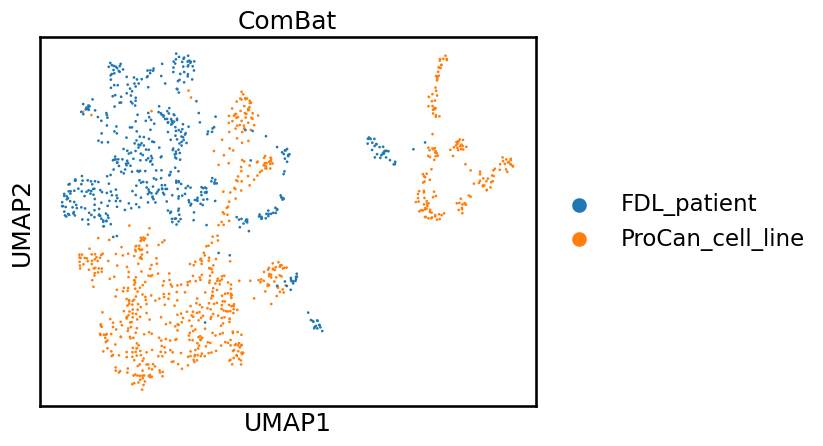

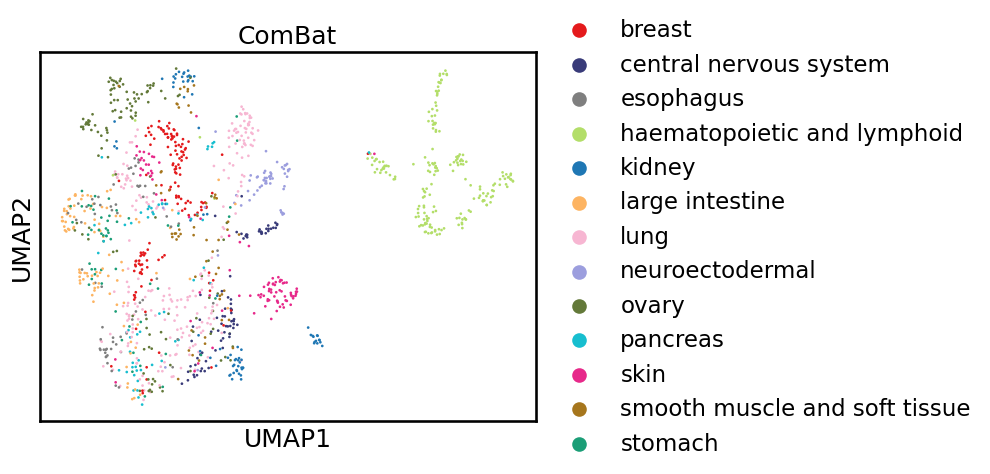

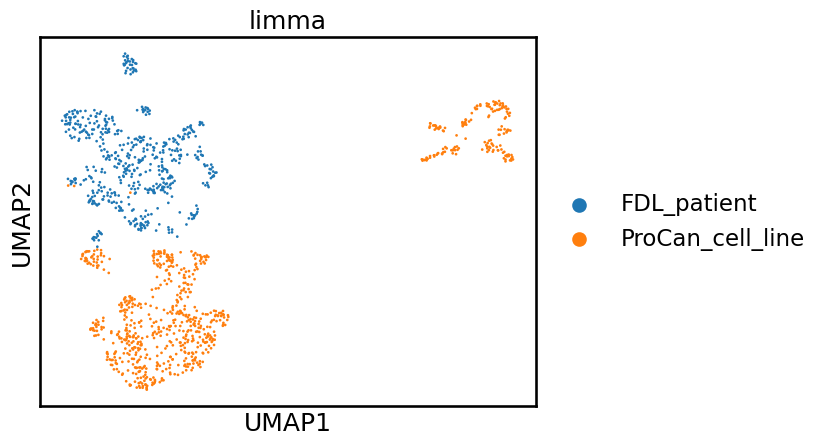

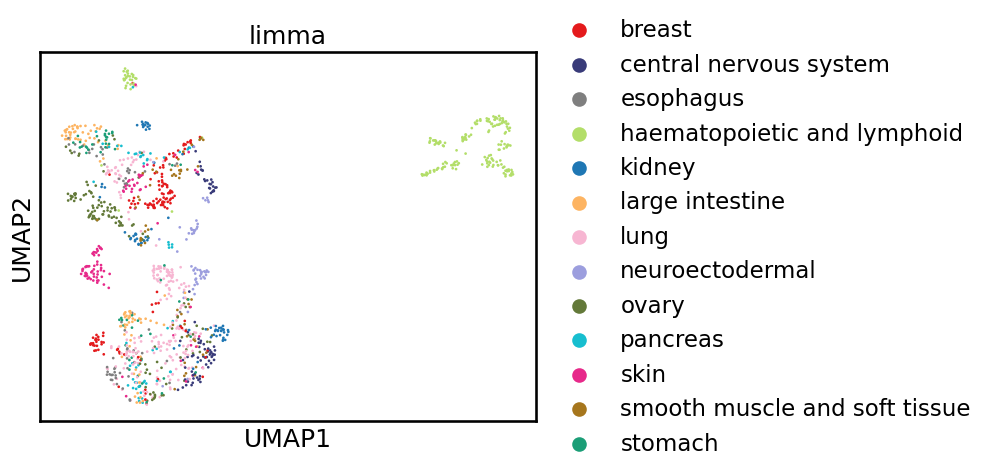

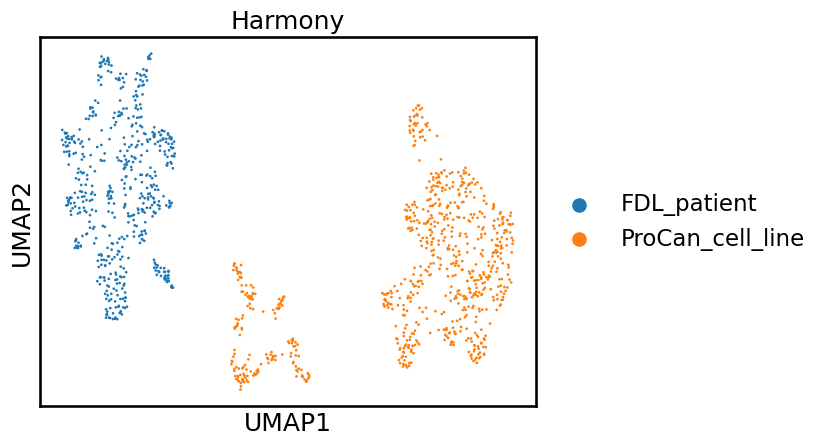

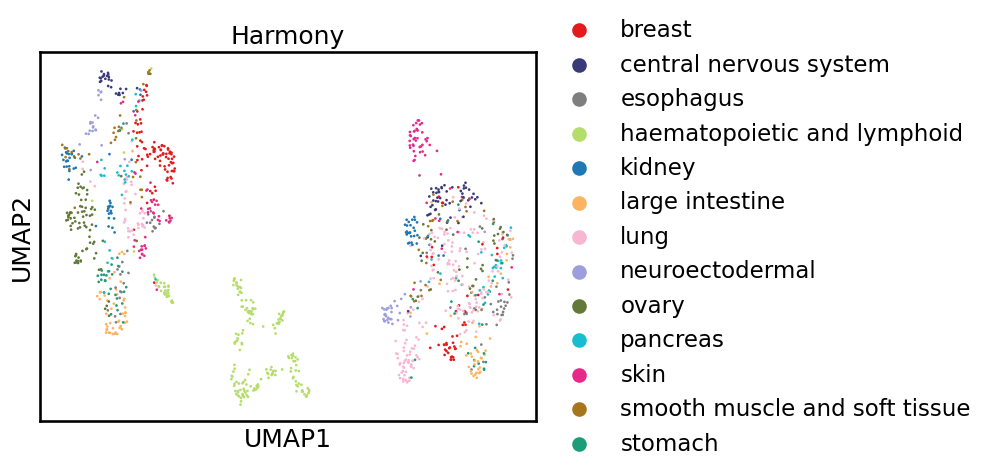

In [33]:
# UMAP on the simple methods

# -----------------------------------------------------------
# ComBat
sc.pp.pca(adata_combat, n_comps=50)
sc.pp.neighbors(adata_combat, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_combat, random_state=42)

sc.pl.umap(
    adata_combat,
    color="data_source",
    legend_loc="right margin",
    frameon=True,
    size=15,
    title="ComBat"
)

sc.pl.umap(
    adata_combat,
    color="joint tissue type",
    legend_loc="right margin",
    frameon=True,
    palette=tissue_palette,
    size=15,
    title="ComBat"
)

# ------------------------------------------------------------------
# limma 
# ------------------------------------------------------------------
sc.pp.pca(adata_limma, n_comps=50)
sc.pp.neighbors(adata_limma, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_limma, random_state=42)

sc.pl.umap(
    adata_limma,
    color="data_source",
    legend_loc="right margin",
    frameon=True,
    size=15,
    title="limma",
)

sc.pl.umap(
    adata_limma,
    color="joint tissue type",
    legend_loc="right margin",
    frameon=True,
    palette=tissue_palette,
    size=15,
    title="limma"
)

# ------------------------------------------------------------------
# harmony
# ------------------------------------------------------------------
# adata_harmony already stored the transformed data in the .X, hence contruct the neighbors and UMAP directly 
sc.pp.neighbors(adata_harmony, n_neighbors=15)
sc.tl.umap(adata_harmony, random_state=42)

sc.pl.umap(
    adata_harmony,
    color="data_source",
    legend_loc="right margin",
    frameon=True,
    size=15,
    title="Harmony",
)

sc.pl.umap(
    adata_harmony,
    color="joint tissue type",
    legend_loc="right margin",
    frameon=True,
    palette=tissue_palette,
    size=15,
    title="Harmony"
)

## Plot the LISI scores

In [34]:
DETERMINISTIC_METHODS = {"original", "combat", "limma", "harmony", "Celligner"}

def plot_lisi_bar(result_dict, title, ylabel="LISI score", method_order=None, ymin=0, ymax=1):

    methods = method_order if method_order is not None else list(result_dict.keys())

    means = []
    stds = []
    colors = []

    for method in methods:

        values = np.atleast_1d(result_dict[method]).astype(float)
        values = values[~np.isnan(values)]

        if len(values) == 0:
            means.append(np.nan)
            stds.append(0.0)
            colors.append("lightgrey")

        elif method in DETERMINISTIC_METHODS or len(values) == 1:
            means.append(values[0])
            stds.append(0.0)
            colors.append("tab:blue")

        else:
            means.append(np.mean(values))
            stds.append(np.std(values, ddof=1) if len(values) > 1 else 0.0)
            colors.append("tab:blue")

    x = np.arange(len(methods))

    plt.figure(figsize=(6,4))
    plt.bar(x, means, yerr=stds, capsize=6, color=colors)

    plt.xticks(x, methods, rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)

    # fixed LISI scale
    plt.ylim(ymin,ymax)

    plt.tight_layout()
    plt.show()

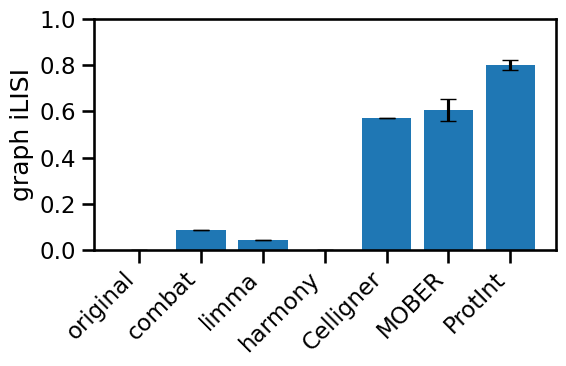

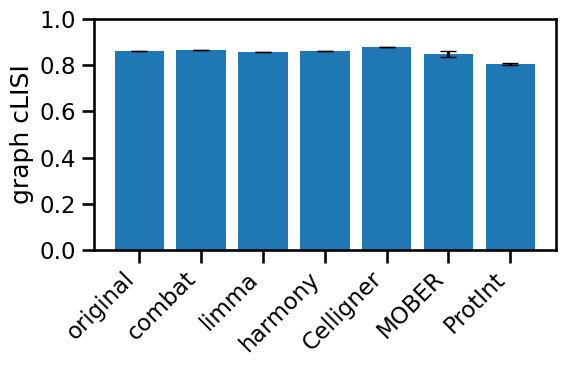

In [35]:
method_order = [
    "original",
    "combat",
    "limma",
    "harmony",
    "Celligner",
    "MOBER",
    "ProtInt"
]

plot_lisi_bar(
    result_iLISI,
    title="",
    ylabel="graph iLISI",
    method_order=method_order,
    ymin=0,ymax=1
)

plot_lisi_bar(
    result_cLISI_tissue,
    title="",
    ylabel="graph cLISI",
    method_order=method_order,
    ymin=0, ymax=1
)

In [36]:
# save the benchmarking results
import pickle

with open(os.path.join(data_output_dir, "result_iLISI.pkl"), "wb") as f:
    pickle.dump(result_iLISI, f)

with open(os.path.join(data_output_dir, "result_cLISI_tissue.pkl"), "wb") as f:
    pickle.dump(result_cLISI_tissue, f)